# Phase-Based Imminence Diagnostics

**Motivation:** We want to know if the vigor data can support a threat imminence story — that defensive vigor tracks the transition from distal to imminent threat. But trials vary structurally in duration (distance, effort, choice), so continuous within-trial temporal alignment is confounded. The phase approach (onset, encounter, terminal) handles this by anchoring to discrete task events.

**Question:** Within the phase framework, is there signal for an imminence story? Specifically:

1. **Encounter transition:** Does the pre→post encounter shift in vigor depend on threat level? (imminence = threat becomes imminent at encounter)
2. **Phase × threat × attack:** Does threat modulate vigor differently across phases, and does actual attack add anything beyond anticipated threat?
3. **Variance structure:** How is vigor variance distributed across subjects, trials, and phases? Which phases carry individual differences vs. state-driven variance?
4. **Phase transitions & model parameters:** Do choice model parameters (z, k, β) differentially predict phase-specific vigor, consistent with a deliberative/reactive dissociation?
5. **Split-half reliability:** Are phase-level individual differences stable enough to link to model parameters?

**Decision rule:** If phase-level contrasts show clean threat × phase interactions with adequate reliability, we have a publishable imminence story using phases. No need to force continuous temporal modeling.

In [3]:
# ── SETUP ─────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

ROOT       = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PROC = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed'
STATS_DIR  = ROOT / 'results' / 'stats'
FIGS_DIR   = ROOT / 'figs'

DPI = 150
THREAT_COLORS = {0.1: '#2196F3', 0.5: '#FF9800', 0.9: '#F44336'}
THREAT_LABELS = {0.1: 'Low (0.1)', 0.5: 'Med (0.5)', 0.9: 'High (0.9)'}
ATTACK_STYLES = {0: ('--', '#999999', 'No attack'), 1: ('-', '#D32F2F', 'Attack')}

plt.style.use('seaborn-v0_8-whitegrid')

# ── Load phase metrics (trial-level, already extracted in NB04) ──
pm = pd.read_parquet(VIGOR_PROC / 'phase_vigor_metrics.parquet')
print(f'Phase metrics: {pm.shape[0]:,} trials, {pm["subj"].nunique()} subjects')
print(f'Columns: {pm.columns.tolist()[:15]}...')

# ── Standardize column names for clarity ──
# NB04 outputs both _resid and _norm variants; we use _resid throughout (demand-corrected)
phase_dvs = {
    'onset_slope': 'onset_slope_resid',
    'onset_mean': 'onset_mean_resid',
    'enc_pre': 'enc_pre_mean_resid',
    'enc_post': 'enc_post_mean_resid',
    'enc_spike': 'enc_spike_resid',
    'term_mean': 'term_mean_resid',
    'term_slope': 'term_slope_resid',
}

# Compute encounter transition magnitude
pm['enc_transition'] = pm['enc_post_mean_resid'] - pm['enc_pre_mean_resid']

# Convenience columns
pm['attack'] = pm['isAttackTrial'].astype(int)
pm['threat_c'] = pm['threat'] - 0.5

# ── Load model parameters ──
params = {}
for p in ['z', 'k', 'beta']:
    fname = f'FET_Exp_Bias_{p}_params.csv'
    df_p = pd.read_csv(STATS_DIR / fname)
    df_p = df_p.rename(columns={'subject': 'subj'})
    params[p] = df_p.set_index('subj')['median']

param_df = pd.DataFrame(params)
param_df.columns = ['z', 'kappa', 'beta']
# Z-score for comparable coefficients
for col in param_df.columns:
    param_df[f'{col}_z'] = (param_df[col] - param_df[col].mean()) / param_df[col].std()

pm = pm.merge(param_df, left_on='subj', right_index=True, how='left')

print(f'\nModel params merged: {pm["z"].notna().sum():,} trials with params')
print(f'Phase DVs available:')
for name, col in phase_dvs.items():
    n = pm[col].notna().sum()
    print(f'  {name:15s} ({col}): {n:,} / {len(pm):,} ({100*n/len(pm):.1f}%)')

Phase metrics: 23,556 trials, 293 subjects
Columns: ['subj', 'trial', 'participantID', 'trialName', 'threat', 'choice', 'outcome', 'isAttackTrial', 'encounterTime', 'trialEscapeTime', 'trialCaptureTime', 'trialEndTime', 'startDistance', 'effort_H', 'distance_H']...

Model params merged: 23,556 trials with params
Phase DVs available:
  onset_slope     (onset_slope_resid): 23,556 / 23,556 (100.0%)
  onset_mean      (onset_mean_resid): 23,556 / 23,556 (100.0%)
  enc_pre         (enc_pre_mean_resid): 16,129 / 23,556 (68.5%)
  enc_post        (enc_post_mean_resid): 16,129 / 23,556 (68.5%)
  enc_spike       (enc_spike_resid): 16,129 / 23,556 (68.5%)
  term_mean       (term_mean_resid): 23,494 / 23,556 (99.7%)
  term_slope      (term_slope_resid): 23,494 / 23,556 (99.7%)


---
## Check 1: Encounter Transition — Does the Pre→Post Shift Depend on Threat and Attack?

The encounter is the discrete imminence event — threat transitions from anticipated to imminent. The key question: does the magnitude of this transition (enc_post − enc_pre) vary with threat level, and does actual predator appearance add to anticipated threat?

**What to look for:**
- Threat × phase interaction: higher threat → bigger pre→post shift (or higher baseline, less room for shift?)
- Attack × phase interaction: actual attack → additional post-encounter boost beyond anticipation
- Threat × attack × phase: does attack amplify the threat effect, or is it additive?

Trials with encounter data: 16,129


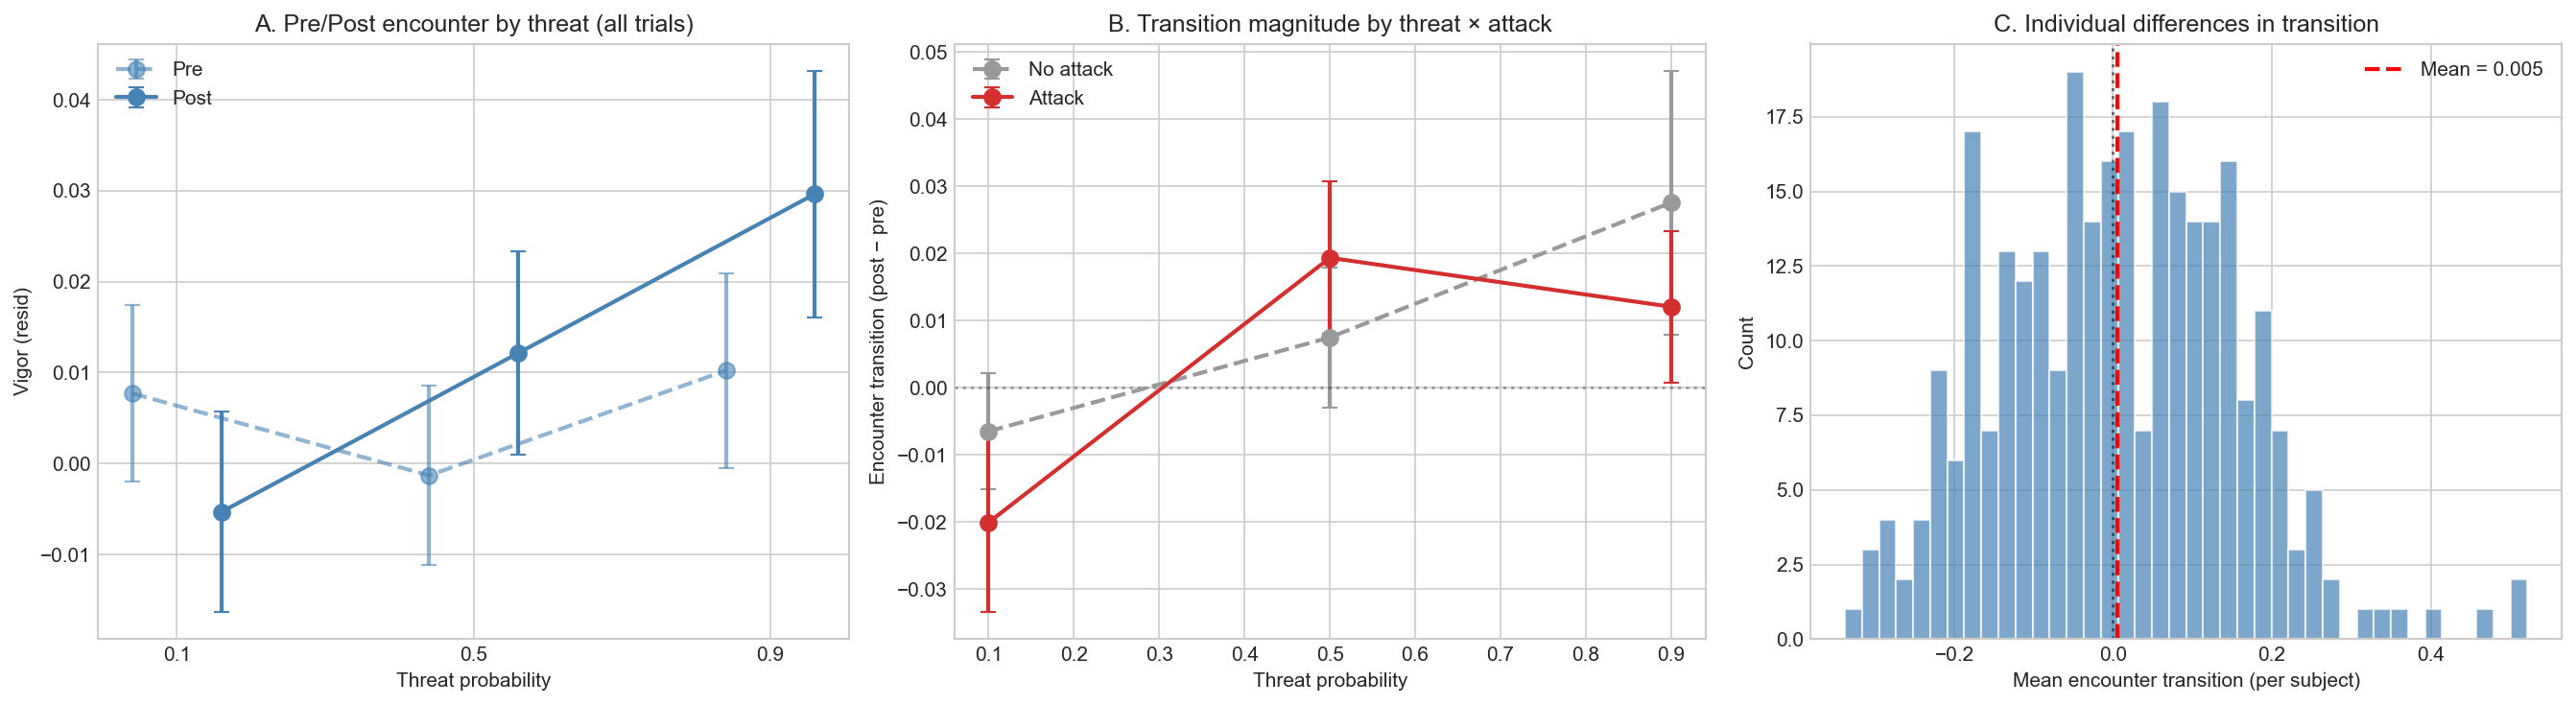


── Encounter transition statistics ──
  Overall transition > 0: M=0.0048, t=0.55, p=5.85e-01
  Threat effect on transition: F=1.61, p=2.00e-01
    threat=0.1: M=-0.0085
    threat=0.5: M=0.0126
    threat=0.9: M=0.0145

  Attack effect on transition: t=2.15, p=3.27e-02
    Attack:    M=0.0124
    No-attack: M=-0.0006


In [4]:
# ── CHECK 1: Encounter transition by threat × attack ─────────────────────────

enc_trials = pm[pm['enc_pre_mean_resid'].notna() & pm['enc_post_mean_resid'].notna()].copy()
print(f'Trials with encounter data: {len(enc_trials):,}')

# ── Panel A: Pre vs Post mean vigor by threat level ──
# Reshape to long format for pre/post
pre_post = []
for _, row in enc_trials.iterrows():
    for phase, col in [('Pre', 'enc_pre_mean_resid'), ('Post', 'enc_post_mean_resid')]:
        pre_post.append({
            'subj': row['subj'], 'trial': row['trial'],
            'threat': row['threat'], 'attack': row['attack'],
            'phase': phase, 'vigor': row[col]
        })
pp = pd.DataFrame(pre_post)

# Subject-level means by threat × phase × attack
subj_pp = (pp.groupby(['subj', 'threat', 'attack', 'phase'])['vigor']
    .mean().reset_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=DPI)

# Panel A: All trials — pre/post by threat
ax = axes[0]
grand_pp = subj_pp.groupby(['threat', 'phase'])['vigor'].agg(['mean', 'sem']).reset_index()
x_pos = {'Pre': -0.15, 'Post': 0.15}
for phase in ['Pre', 'Post']:
    d = grand_pp[grand_pp['phase'] == phase]
    xs = np.arange(3) + x_pos[phase]
    ls = '--' if phase == 'Pre' else '-'
    ax.errorbar(xs, d['mean'], yerr=d['sem'], fmt=f'o{ls}', 
                color='steelblue', markersize=8, capsize=4, linewidth=2,
                alpha=0.6 if phase == 'Pre' else 1.0, label=phase)
ax.set_xticks(range(3))
ax.set_xticklabels(['0.1', '0.5', '0.9'])
ax.set_xlabel('Threat probability')
ax.set_ylabel('Vigor (resid)')
ax.set_title('A. Pre/Post encounter by threat (all trials)')
ax.legend()

# Panel B: Transition magnitude (post − pre) by threat × attack
ax = axes[1]
trans_subj = (enc_trials.groupby(['subj', 'threat', 'attack'])['enc_transition']
    .mean().reset_index())
trans_grand = (trans_subj.groupby(['threat', 'attack'])['enc_transition']
    .agg(['mean', 'sem']).reset_index())

for atk in [0, 1]:
    ls, color, label = ATTACK_STYLES[atk]
    d = trans_grand[trans_grand['attack'] == atk]
    ax.errorbar([0.1, 0.5, 0.9], d['mean'], yerr=d['sem'],
                fmt=f'o{ls}', color=color, markersize=8, capsize=4, linewidth=2, label=label)
ax.axhline(0, color='k', linestyle=':', alpha=0.3)
ax.set_xlabel('Threat probability')
ax.set_ylabel('Encounter transition (post − pre)')
ax.set_title('B. Transition magnitude by threat × attack')
ax.legend()

# Panel C: Distribution of per-subject transition magnitudes
ax = axes[2]
subj_trans = enc_trials.groupby('subj')['enc_transition'].mean()
ax.hist(subj_trans, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(0, color='k', linestyle=':', alpha=0.5)
ax.axvline(subj_trans.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {subj_trans.mean():.3f}')
ax.set_xlabel('Mean encounter transition (per subject)')
ax.set_ylabel('Count')
ax.set_title('C. Individual differences in transition')
ax.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / 'check1_encounter_transition.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Statistical tests ──
print('\n── Encounter transition statistics ──')

# 1. Is transition > 0 overall?
t_stat, p_trans = stats.ttest_1samp(subj_trans, 0)
print(f'  Overall transition > 0: M={subj_trans.mean():.4f}, t={t_stat:.2f}, p={p_trans:.2e}')

# 2. Threat effect on transition (within-subject ANOVA on subject × threat means)
trans_by_threat = enc_trials.groupby(['subj', 'threat'])['enc_transition'].mean().reset_index()
groups = [trans_by_threat[trans_by_threat['threat'] == th]['enc_transition'].values 
          for th in [0.1, 0.5, 0.9]]
F_threat, p_threat = stats.f_oneway(*groups)
print(f'  Threat effect on transition: F={F_threat:.2f}, p={p_threat:.2e}')

# Per-threat means
for th in [0.1, 0.5, 0.9]:
    m = trans_by_threat[trans_by_threat['threat'] == th]['enc_transition'].mean()
    print(f'    threat={th}: M={m:.4f}')

# 3. Attack effect on transition
trans_by_attack = enc_trials.groupby(['subj', 'attack'])['enc_transition'].mean().reset_index()
atk_means = trans_by_attack.pivot(index='subj', columns='attack', values='enc_transition').dropna()
t_atk, p_atk = stats.ttest_rel(atk_means[1], atk_means[0])
print(f'\n  Attack effect on transition: t={t_atk:.2f}, p={p_atk:.2e}')
print(f'    Attack:    M={atk_means[1].mean():.4f}')
print(f'    No-attack: M={atk_means[0].mean():.4f}')

---
## Check 2: Full Phase Profile — Onset → Pre-Encounter → Post-Encounter → Terminal

**Question:** How does vigor evolve across the full sequence of task-defined phases, and how does threat modulate each phase?

This is the imminence story told through phases: onset (anticipatory preparation), pre-encounter (sustained effort under potential threat), post-encounter (reactive response), terminal (escape execution). Each phase has a clean operational definition tied to task events, avoiding the temporal alignment problem.

**What to look for:**
- Monotonic threat gradient across phases (higher threat → higher vigor at each phase?)
- Or: threat selectively affects some phases but not others (e.g., onset and pre-encounter but not terminal)
- Phase × threat interaction pattern that maps onto the imminence continuum

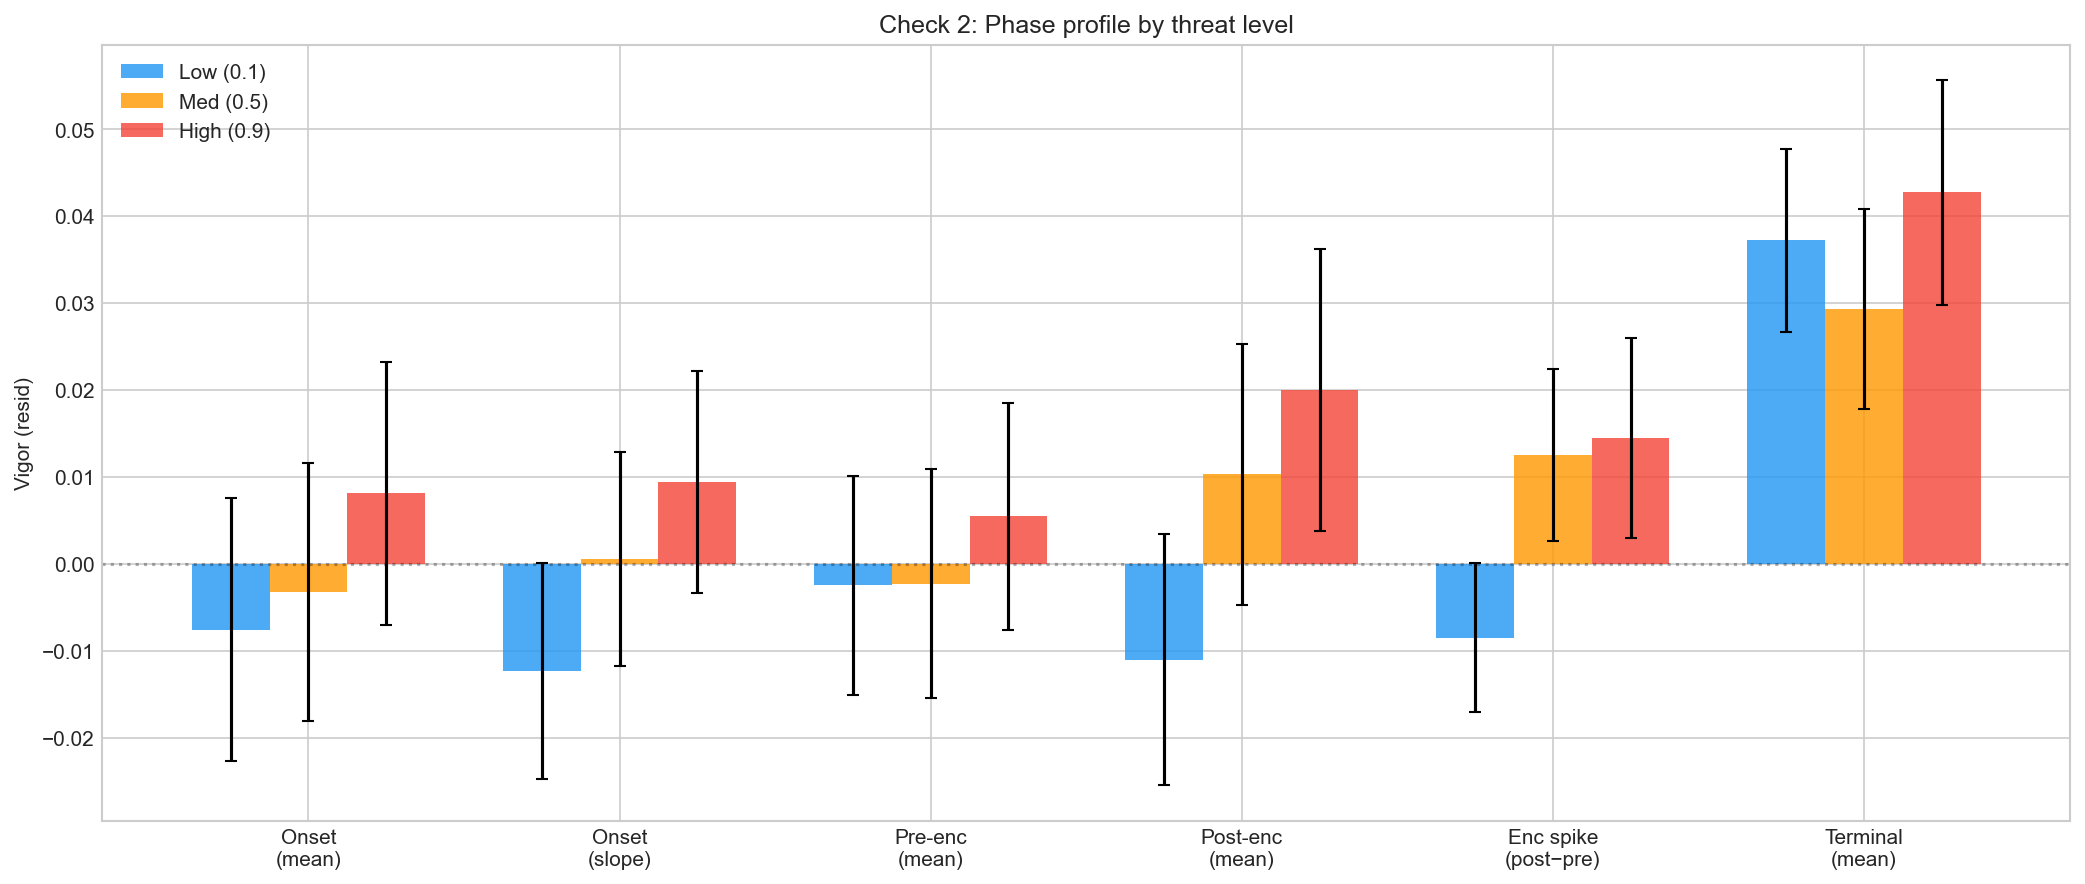

── Threat effect per phase DV (one-way ANOVA on subject×threat means) ──

  Phase DV                       Low      Med     High        F            p
  ──────────────────────────────────────────────────────────────────────
  Onset (mean)               -0.0076  -0.0033   0.0081     0.29    7.47e-01 
  Onset (slope)              -0.0123   0.0006   0.0094     0.77    4.65e-01 
  Pre-enc (mean)             -0.0025  -0.0023   0.0054     0.12    8.85e-01 
  Post-enc (mean)            -0.0110   0.0103   0.0199     1.08    3.41e-01 
  Enc spike (post−pre)       -0.0085   0.0126   0.0145     1.61    2.00e-01 
  Terminal (mean)             0.0372   0.0293   0.0427     0.33    7.17e-01 


In [5]:
# ── CHECK 2: Full phase profile by threat ────────────────────────────────────

# Define the phase sequence (columns from phase_vigor_metrics)
phase_cols = [
    ('Onset\n(mean)', 'onset_mean_resid'),
    ('Onset\n(slope)', 'onset_slope_resid'),
    ('Pre-enc\n(mean)', 'enc_pre_mean_resid'),
    ('Post-enc\n(mean)', 'enc_post_mean_resid'),
    ('Enc spike\n(post−pre)', 'enc_spike_resid'),
    ('Terminal\n(mean)', 'term_mean_resid'),
]

# Compute subject × threat means for each phase DV
phase_profiles = {}
for label, col in phase_cols:
    subj_threat = pm.groupby(['subj', 'threat'])[col].mean().reset_index()
    grand = subj_threat.groupby('threat')[col].agg(['mean', 'sem']).reset_index()
    phase_profiles[label] = grand

fig, ax = plt.subplots(figsize=(14, 6), dpi=DPI)

x = np.arange(len(phase_cols))
width = 0.25
offsets = {0.1: -width, 0.5: 0, 0.9: width}

for th in [0.1, 0.5, 0.9]:
    means = [phase_profiles[label][phase_profiles[label]['threat'] == th]['mean'].values[0] 
             for label, _ in phase_cols]
    sems = [phase_profiles[label][phase_profiles[label]['threat'] == th]['sem'].values[0] 
            for label, _ in phase_cols]
    ax.bar(x + offsets[th], means, width, yerr=sems, capsize=3,
           color=THREAT_COLORS[th], alpha=0.8, label=THREAT_LABELS[th])

ax.set_xticks(x)
ax.set_xticklabels([label for label, _ in phase_cols])
ax.set_ylabel('Vigor (resid)')
ax.set_title('Check 2: Phase profile by threat level')
ax.legend()
ax.axhline(0, color='k', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'check2_phase_profile.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Threat effect per phase (within-subject ANOVA) ──
print('── Threat effect per phase DV (one-way ANOVA on subject×threat means) ──\n')
print(f'  {"Phase DV":<25s} {"Low":>8s} {"Med":>8s} {"High":>8s} {"F":>8s} {"p":>12s}')
print('  ' + '─' * 70)

for label, col in phase_cols:
    subj_threat = pm.groupby(['subj', 'threat'])[col].mean().reset_index()
    groups = [subj_threat[subj_threat['threat'] == th][col].dropna().values 
              for th in [0.1, 0.5, 0.9]]
    # Only test if all groups have data
    if all(len(g) > 10 for g in groups):
        F, p = stats.f_oneway(*groups)
        means = [g.mean() for g in groups]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f'  {label.replace(chr(10)," "):25s} {means[0]:>8.4f} {means[1]:>8.4f} '
              f'{means[2]:>8.4f} {F:>8.2f} {p:>11.2e} {sig}')
    else:
        print(f'  {label.replace(chr(10)," "):25s} — insufficient data')

---
## Check 3: Variance Structure — ICC per Phase DV

**Question:** Which phase DVs carry stable individual differences (high ICC → between-subject) vs. are state-driven (low ICC → within-subject, trial-level)?

This tells us:
- **High ICC phases** → candidates for linking to model parameters (z, k, β)
- **Low ICC phases** → driven by trial-level state (threat, distance, effort), not person-level traits
- A clean dissociation (some phases high ICC, others low) supports the deliberative/reactive framing

── ICC(1) for phase DVs ──
  DV                      ICC  % Between   % Within  Trials/subj
  ────────────────────────────────────────────────────────────
  onset_mean            0.737      73.7%      26.3%        80.4  ●
  onset_slope           0.480      48.0%      52.0%        80.4  ●
  enc_pre_mean          0.418      41.8%      58.2%        55.0  ●
  enc_post_mean         0.418      41.8%      58.2%        55.0  ●
  enc_spike             0.183      18.3%      81.7%        55.0  ●
  enc_transition        0.183      18.3%      81.7%        55.0  ●
  term_mean             0.329      32.9%      67.1%        80.2  ●
  term_slope            0.029       2.9%      97.1%        80.2  ○


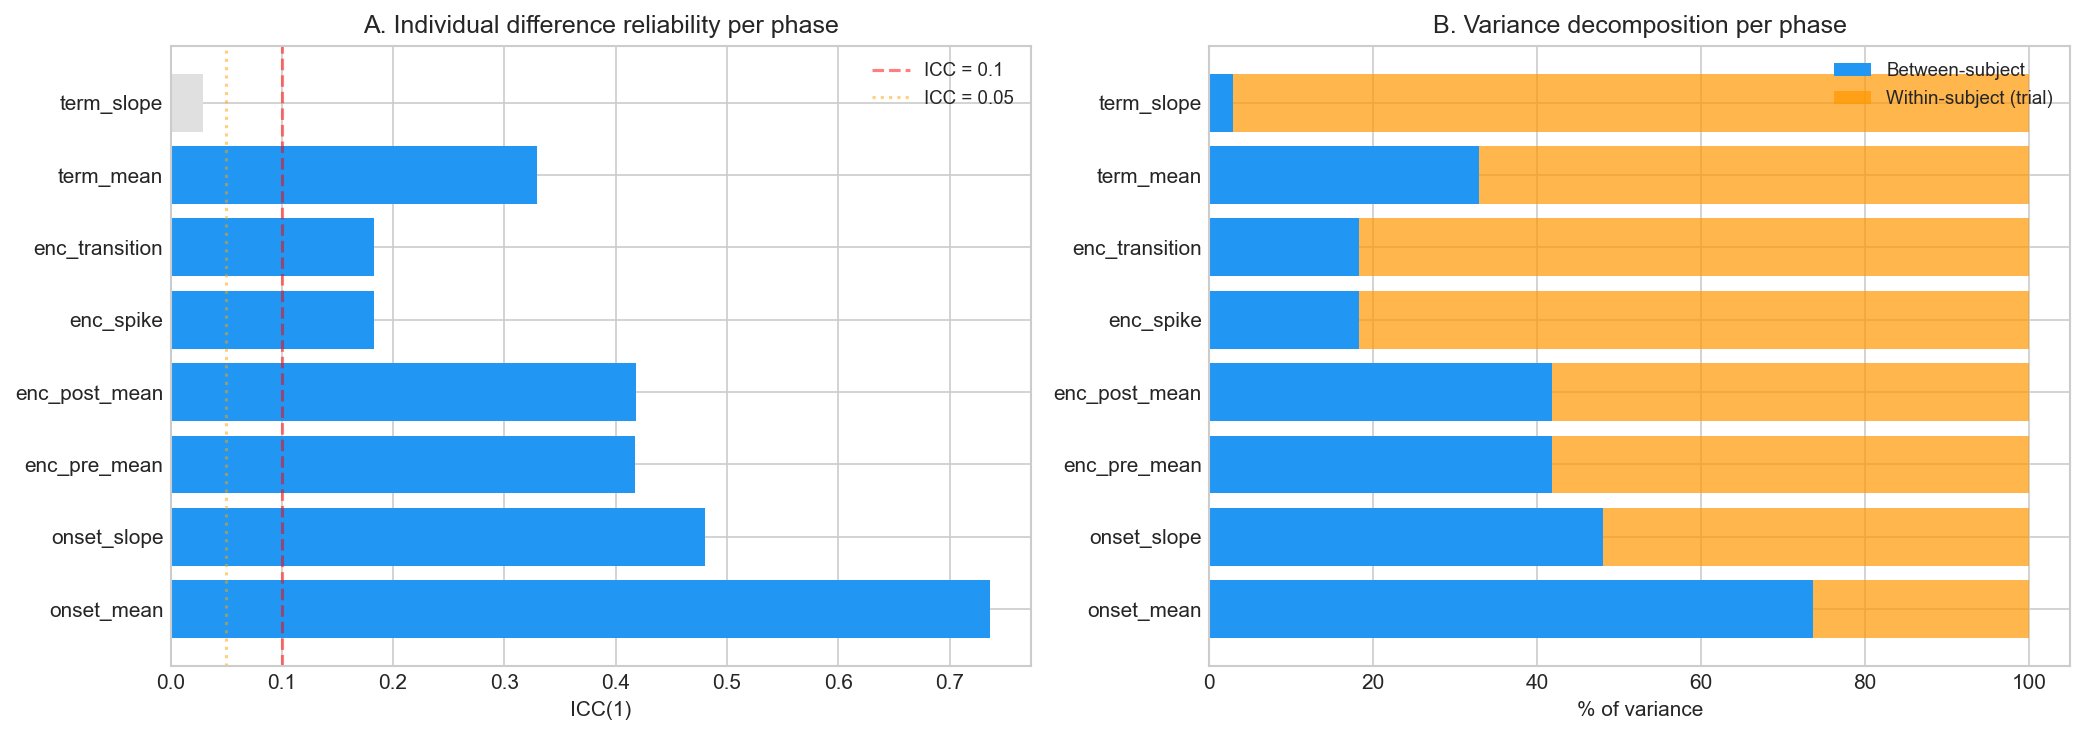


  High-ICC DVs (>0.1): onset_mean, onset_slope, enc_pre_mean, enc_post_mean, enc_spike, enc_transition, term_mean
  Low-ICC DVs (<0.05): term_slope


In [6]:
# ── CHECK 3: ICC per phase DV ────────────────────────────────────────────────

all_dvs = [
    ('onset_mean', 'onset_mean_resid'),
    ('onset_slope', 'onset_slope_resid'),
    ('enc_pre_mean', 'enc_pre_mean_resid'),
    ('enc_post_mean', 'enc_post_mean_resid'),
    ('enc_spike', 'enc_spike_resid'),
    ('enc_transition', 'enc_transition'),
    ('term_mean', 'term_mean_resid'),
    ('term_slope', 'term_slope_resid'),
]

icc_results = []
for name, col in all_dvs:
    subset = pm[['subj', col]].dropna()
    if len(subset) < 100:
        continue
    
    subj_means = subset.groupby('subj')[col].mean()
    var_between = subj_means.var()
    var_within = subset.groupby('subj')[col].var().mean()
    icc = var_between / (var_between + var_within) if (var_between + var_within) > 0 else 0
    n_trials = subset.groupby('subj')[col].count().mean()
    
    icc_results.append({
        'DV': name, 'col': col, 'ICC': icc,
        'var_between': var_between, 'var_within': var_within,
        'pct_between': 100 * var_between / (var_between + var_within),
        'k_bar': n_trials,
    })

icc_df = pd.DataFrame(icc_results)

print('── ICC(1) for phase DVs ──')
print(f'  {"DV":<20s} {"ICC":>6s} {"% Between":>10s} {"% Within":>10s} {"Trials/subj":>12s}')
print('  ' + '─' * 60)
for _, row in icc_df.iterrows():
    marker = '●' if row['ICC'] > 0.1 else '○'
    print(f'  {row["DV"]:<20s} {row["ICC"]:>6.3f} {row["pct_between"]:>9.1f}% '
          f'{100-row["pct_between"]:>9.1f}% {row["k_bar"]:>11.1f}  {marker}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=DPI)

# Panel A: ICC bar chart
ax = axes[0]
colors = ['#2196F3' if icc > 0.1 else '#BBDEFB' if icc > 0.05 else '#E0E0E0' 
          for icc in icc_df['ICC']]
ax.barh(icc_df['DV'], icc_df['ICC'], color=colors)
ax.axvline(0.1, color='red', linestyle='--', alpha=0.5, label='ICC = 0.1')
ax.axvline(0.05, color='orange', linestyle=':', alpha=0.5, label='ICC = 0.05')
ax.set_xlabel('ICC(1)')
ax.set_title('A. Individual difference reliability per phase')
ax.legend(fontsize=9)

# Panel B: Stacked bar (between vs within variance)
ax = axes[1]
ax.barh(icc_df['DV'], icc_df['pct_between'], color='#2196F3', label='Between-subject')
ax.barh(icc_df['DV'], 100 - icc_df['pct_between'], left=icc_df['pct_between'],
        color='#FF9800', alpha=0.7, label='Within-subject (trial)')
ax.set_xlabel('% of variance')
ax.set_title('B. Variance decomposition per phase')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'check3_icc_phases.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n  High-ICC DVs (>0.1): {", ".join(icc_df[icc_df["ICC"]>0.1]["DV"].tolist()) or "none"}')
print(f'  Low-ICC DVs (<0.05): {", ".join(icc_df[icc_df["ICC"]<0.05]["DV"].tolist()) or "none"}')

---
## Check 4: Model Parameters × Phase DVs — Selective Prediction Pattern

**Question:** Do z, k, and β selectively predict different phase DVs, consistent with a dissociation between anticipatory (deliberative, parameter-governed) and reactive (state-driven) vigor?

**Method:** For each phase DV, regress subject-level mean on z_z, kappa_z, beta_z simultaneously. Report standardized betas and adj. R². This replicates the NB06/NB08 analysis but organized by the imminence framework.

**What to look for:**
- Onset/pre-encounter phases predicted by model params → deliberative, anticipatory control
- Encounter spike / transition NOT predicted by params → reactive, state-driven
- Terminal: ambiguous (could be either)
- k as global suppressor across all phases vs. z/β as selective

Subject-level regression: N = 293 subjects

  Phase DV                    z        k        β   adj.R²        F       p(F)
  ────────────────────────────────────────────────────────────────────────
  onset_mean             +0.215   -0.128   +0.078    0.048     5.91  6.34e-04 ***
  onset_slope            +0.128   -0.208   +0.175    0.062     7.46  7.89e-05 ***
  enc_pre_mean           +0.175   -0.165   +0.073    0.042     5.23  1.58e-03 **
  enc_post_mean          +0.077   -0.185   +0.135    0.037     4.77  2.90e-03 **
  enc_spike              -0.119   -0.073   +0.120    0.024     3.38  1.87e-02 *
  enc_transition         -0.119   -0.073   +0.120    0.024     3.38  1.87e-02 *
  term_mean              -0.045   -0.221   +0.067    0.044     5.47  1.14e-03 **
  term_slope             -0.193   +0.015   -0.095    0.035     4.50  4.20e-03 **


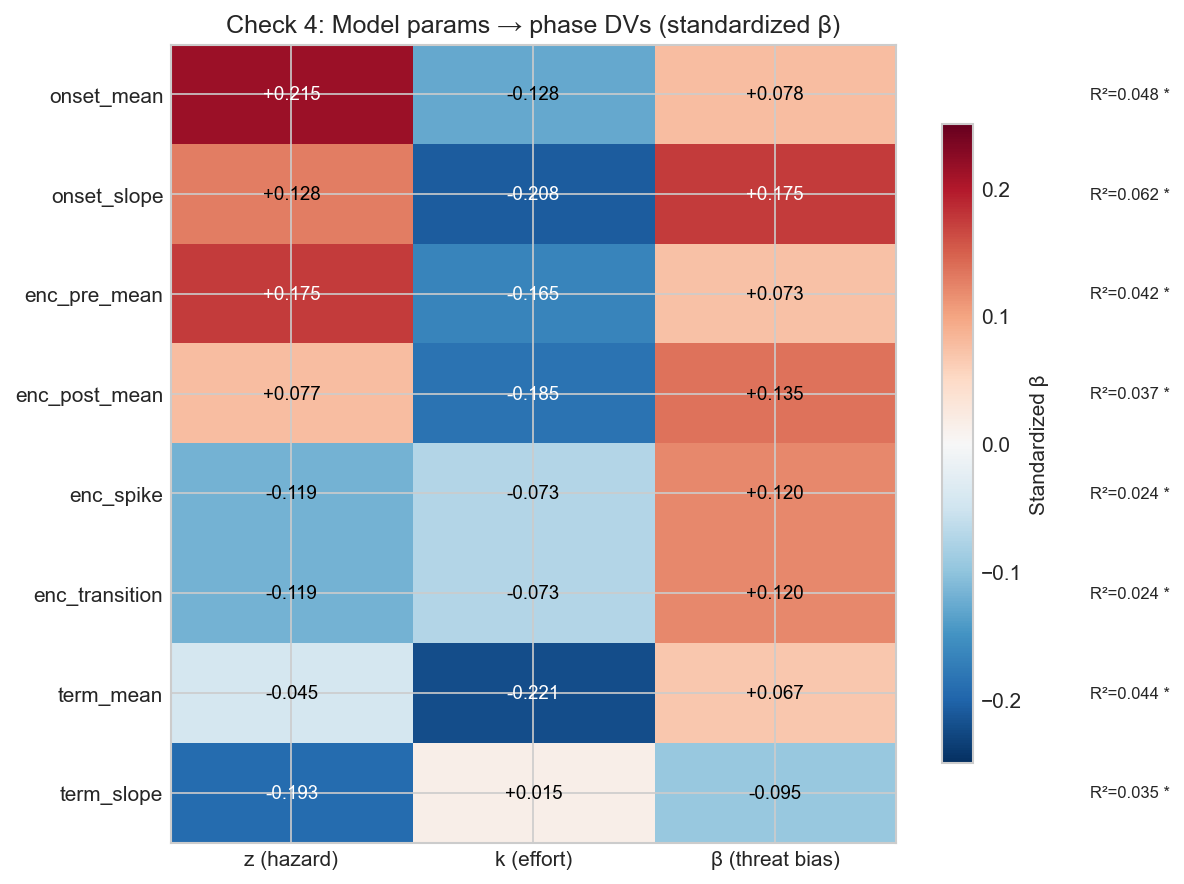

In [7]:
# ── CHECK 4: Model params × phase DVs ────────────────────────────────────────

from sklearn.linear_model import LinearRegression

# Subject-level means for each DV
subj_dvs = pm.groupby('subj').agg({
    'onset_mean_resid': 'mean',
    'onset_slope_resid': 'mean',
    'enc_pre_mean_resid': 'mean', 
    'enc_post_mean_resid': 'mean',
    'enc_spike_resid': 'mean',
    'enc_transition': 'mean',
    'term_mean_resid': 'mean',
    'term_slope_resid': 'mean',
    'z_z': 'first', 'kappa_z': 'first', 'beta_z': 'first',
}).dropna()

print(f'Subject-level regression: N = {len(subj_dvs)} subjects\n')

predictors = ['z_z', 'kappa_z', 'beta_z']
X = subj_dvs[predictors].values

reg_results = []
print(f'  {"Phase DV":<20s} {"z":>8s} {"k":>8s} {"β":>8s} {"adj.R²":>8s} {"F":>8s} {"p(F)":>10s}')
print('  ' + '─' * 72)

for name, col in all_dvs:
    y = subj_dvs[col].values
    mask = ~np.isnan(y)
    if mask.sum() < 50:
        continue
    
    X_valid = X[mask]
    y_valid = y[mask]
    
    # OLS regression
    reg = LinearRegression().fit(X_valid, y_valid)
    y_pred = reg.predict(X_valid)
    
    # Stats
    n = len(y_valid)
    k_pred = len(predictors)
    ss_res = np.sum((y_valid - y_pred)**2)
    ss_tot = np.sum((y_valid - y_valid.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k_pred - 1)
    
    # F-test
    ms_reg = (ss_tot - ss_res) / k_pred if k_pred > 0 else 0
    ms_res = ss_res / (n - k_pred - 1) if (n - k_pred - 1) > 0 else 1
    F_stat = ms_reg / ms_res
    p_F = 1 - stats.f.cdf(F_stat, k_pred, n - k_pred - 1)
    
    # Standardized betas (already z-scored predictors, but y is not)
    y_std = (y_valid - y_valid.mean()) / y_valid.std() if y_valid.std() > 0 else y_valid
    reg_std = LinearRegression().fit(X_valid, y_std)
    betas = reg_std.coef_
    
    sig = '***' if p_F < 0.001 else '**' if p_F < 0.01 else '*' if p_F < 0.05 else ''
    print(f'  {name:<20s} {betas[0]:>+8.3f} {betas[1]:>+8.3f} {betas[2]:>+8.3f} '
          f'{adj_r2:>8.3f} {F_stat:>8.2f} {p_F:>9.2e} {sig}')
    
    reg_results.append({
        'DV': name, 'beta_z': betas[0], 'beta_k': betas[1], 'beta_beta': betas[2],
        'adj_r2': adj_r2, 'F': F_stat, 'p': p_F,
    })

reg_df = pd.DataFrame(reg_results)

# ── Heatmap of standardized betas ──
fig, ax = plt.subplots(figsize=(8, 6), dpi=DPI)

heat_data = reg_df[['DV', 'beta_z', 'beta_k', 'beta_beta']].set_index('DV')
heat_data.columns = ['z (hazard)', 'k (effort)', 'β (threat bias)']

im = ax.imshow(heat_data.values, cmap='RdBu_r', aspect='auto', vmin=-0.25, vmax=0.25)
ax.set_xticks(range(3))
ax.set_xticklabels(heat_data.columns)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index)

# Add text annotations
for i in range(len(heat_data)):
    for j in range(3):
        val = heat_data.values[i, j]
        color = 'white' if abs(val) > 0.15 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=9, color=color)

# Mark significant models
for i, row in reg_df.iterrows():
    if row['p'] < 0.05:
        ax.text(3.3, i, f'R²={row["adj_r2"]:.3f} *', fontsize=8, va='center')
    else:
        ax.text(3.3, i, f'R²={row["adj_r2"]:.3f}', fontsize=8, va='center', color='gray')

ax.set_title('Check 4: Model params → phase DVs (standardized β)')
plt.colorbar(im, ax=ax, label='Standardized β', shrink=0.8)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'check4_param_phase_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Check 5: Split-Half Reliability of Phase DVs

**Question:** Are per-subject phase DV means stable across trial splits? This determines whether individual differences in each phase are reliable enough to meaningfully correlate with model parameters.

**Method:** For each subject, split trials into odd/even. Compute per-phase DV means for each half. Correlate across halves. Also apply Spearman-Brown correction for full-test reliability.

**Pass criterion:** Spearman-Brown r > 0.5 → reliable individual differences for that phase DV.

── Split-half reliability per phase DV ──

  DV                    r(half)    r(SB)     N  Reliable?
  ───────────────────────────────────────────────────────
  onset_mean              0.987    0.994   293        YES
  onset_slope             0.966    0.983   293        YES
  enc_pre_mean            0.895    0.945   292        YES
  enc_post_mean           0.908    0.952   292        YES
  enc_spike               0.723    0.839   292        YES
  enc_transition          0.723    0.839   292        YES
  term_mean               0.913    0.955   293        YES
  term_slope              0.248    0.397   293   marginal


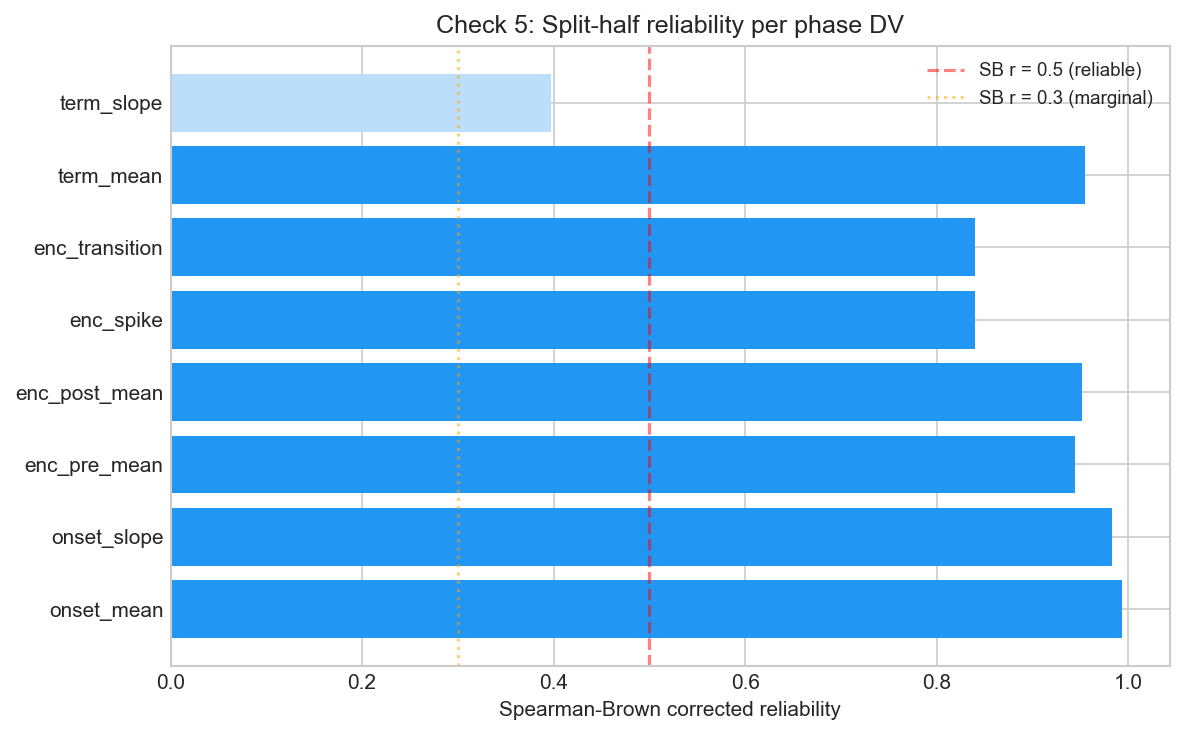

In [8]:
# ── CHECK 5: Split-half reliability of phase DVs ────────────────────────────

# Assign odd/even split within each subject
pm_sh = pm.sort_values(['subj', 'trial']).copy()
pm_sh['trial_idx'] = pm_sh.groupby('subj').cumcount()
pm_sh['half'] = pm_sh['trial_idx'] % 2  # 0 = even, 1 = odd

dv_cols = [col for _, col in all_dvs]

sh_results = []
for name, col in all_dvs:
    # Per-subject, per-half means
    half_means = pm_sh.groupby(['subj', 'half'])[col].mean().reset_index()
    wide = half_means.pivot(index='subj', columns='half', values=col).dropna()
    
    if len(wide) < 50:
        continue
    
    r, p = stats.pearsonr(wide[0], wide[1])
    r_sb = 2 * r / (1 + r) if r > 0 else 0  # Spearman-Brown
    
    sh_results.append({
        'DV': name, 'r_half': r, 'p': p, 'r_sb': r_sb, 'N': len(wide)
    })

sh_df = pd.DataFrame(sh_results)

print('── Split-half reliability per phase DV ──\n')
print(f'  {"DV":<20s} {"r(half)":>8s} {"r(SB)":>8s} {"N":>5s} {"Reliable?":>10s}')
print('  ' + '─' * 55)
for _, row in sh_df.iterrows():
    reliable = 'YES' if row['r_sb'] > 0.5 else 'marginal' if row['r_sb'] > 0.3 else 'NO'
    print(f'  {row["DV"]:<20s} {row["r_half"]:>8.3f} {row["r_sb"]:>8.3f} {row["N"]:>5.0f} '
          f'{reliable:>10s}')

fig, ax = plt.subplots(figsize=(8, 5), dpi=DPI)

colors_sh = ['#2196F3' if r > 0.5 else '#BBDEFB' if r > 0.3 else '#E0E0E0' 
             for r in sh_df['r_sb']]
ax.barh(sh_df['DV'], sh_df['r_sb'], color=colors_sh)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='SB r = 0.5 (reliable)')
ax.axvline(0.3, color='orange', linestyle=':', alpha=0.5, label='SB r = 0.3 (marginal)')
ax.set_xlabel('Spearman-Brown corrected reliability')
ax.set_title('Check 5: Split-half reliability per phase DV')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'check5_split_half_phases.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Summary & Interpretation

In [9]:
# ── SUMMARY ───────────────────────────────────────────────────────────────────

print('=' * 70)
print('PHASE-BASED IMMINENCE DIAGNOSTICS — SUMMARY')
print('=' * 70)

print('''
CHECK 1: Encounter Transition
  Does the pre→post encounter shift depend on threat and attack?
''')
print(f'  Transition > 0: t={t_stat:.2f}, p={p_trans:.2e}')
print(f'  Threat effect:  F={F_threat:.2f}, p={p_threat:.2e}')
print(f'  Attack effect:  t={t_atk:.2f}, p={p_atk:.2e}')

print('''
CHECK 2: Phase Profile by Threat
  Which phases show threat modulation? (see ANOVA table above)
  Key: phases with strong threat effects = state-driven (reactive)
       phases with weak threat effects = person-driven (deliberative)
''')

print('CHECK 3: ICC per Phase DV')
for _, row in icc_df.iterrows():
    tag = 'TRAIT' if row['ICC'] > 0.1 else 'STATE' if row['ICC'] < 0.05 else 'mixed'
    print(f'  {row["DV"]:<20s} ICC={row["ICC"]:.3f} → {tag}')

print('\nCHECK 4: Model Parameters → Phase DVs')
for _, row in reg_df.iterrows():
    sig = '*' if row['p'] < 0.05 else ''
    print(f'  {row["DV"]:<20s} adj.R²={row["adj_r2"]:.3f} {sig}')

print('\nCHECK 5: Split-Half Reliability')
for _, row in sh_df.iterrows():
    tag = 'RELIABLE' if row['r_sb'] > 0.5 else 'marginal' if row['r_sb'] > 0.3 else 'unreliable'
    print(f'  {row["DV"]:<20s} SB r={row["r_sb"]:.3f} → {tag}')

print('\n' + '─' * 70)
print('INTERPRETATION GUIDE:')
print('─' * 70)
print('''
  The imminence story is publishable if:

  1. Encounter transition depends on threat (Check 1) — the discrete
     imminence event (predator appearance) modulates vigor

  2. Threat selectively affects certain phases (Check 2) — not just a
     global "press harder" effect, but a phase-specific pattern

  3. ICC dissociation (Check 3) — anticipatory phases have higher ICC
     (person-level, linkable to params), reactive phases have lower ICC
     (state-driven, trial-specific)

  4. Model params selectively predict anticipatory but not reactive
     phases (Check 4) — the deliberative/reactive dissociation

  5. The phases that link to model params are reliable (Check 5) —
     the individual differences are real, not noise

  If all 5 hold → clean phase-based imminence story for the paper.
  If only 1-3 hold → descriptive imminence story without param linkage.
  If Check 1 fails → no imminence story in the vigor data.
''')

PHASE-BASED IMMINENCE DIAGNOSTICS — SUMMARY

CHECK 1: Encounter Transition
  Does the pre→post encounter shift depend on threat and attack?

  Transition > 0: t=0.55, p=5.85e-01
  Threat effect:  F=1.61, p=2.00e-01
  Attack effect:  t=2.15, p=3.27e-02

CHECK 2: Phase Profile by Threat
  Which phases show threat modulation? (see ANOVA table above)
  Key: phases with strong threat effects = state-driven (reactive)
       phases with weak threat effects = person-driven (deliberative)

CHECK 3: ICC per Phase DV
  onset_mean           ICC=0.737 → TRAIT
  onset_slope          ICC=0.480 → TRAIT
  enc_pre_mean         ICC=0.418 → TRAIT
  enc_post_mean        ICC=0.418 → TRAIT
  enc_spike            ICC=0.183 → TRAIT
  enc_transition       ICC=0.183 → TRAIT
  term_mean            ICC=0.329 → TRAIT
  term_slope           ICC=0.029 → STATE

CHECK 4: Model Parameters → Phase DVs
  onset_mean           adj.R²=0.048 *
  onset_slope          adj.R²=0.062 *
  enc_pre_mean         adj.R²=0.042 *
  enc_

---
## Check 6: Attack Contrast × Model Parameters

The one clean group-level effect is the attack contrast (t=2.15, p=0.033): vigor increases more from pre→post encounter on attack trials than non-attack trials. This is the discrete imminence signal.

**Key questions:**
1. Does this attack-driven boost vary across phase DVs? (Is it specific to enc_spike, or does attack also change onset, terminal?)
2. Do model parameters moderate the attack boost? (Do high-z people show a bigger attack effect? Does k constrain it?)
3. Per-subject: compute the attack effect (mean vigor on attack − mean vigor on non-attack) for each phase DV, then regress on z, k, β.

In [ ]:
# ── CHECK 6a: Attack effect per phase DV ──────────────────────────────────────

# For each phase DV, compute per-subject mean on attack vs non-attack trials
# Then test paired difference

enc_dvs = [
    ('enc_pre_mean', 'enc_pre_mean_resid'),
    ('enc_post_mean', 'enc_post_mean_resid'),
    ('enc_spike', 'enc_spike_resid'),
    ('enc_transition', 'enc_transition'),
]

# Also test onset and terminal (attack status is known at trial level for all phases)
all_phase_dvs = [
    ('onset_mean', 'onset_mean_resid'),
    ('onset_slope', 'onset_slope_resid'),
    ('enc_pre_mean', 'enc_pre_mean_resid'),
    ('enc_post_mean', 'enc_post_mean_resid'),
    ('enc_spike', 'enc_spike_resid'),
    ('term_mean', 'term_mean_resid'),
    ('term_slope', 'term_slope_resid'),
]

print('── Attack effect per phase DV (paired t-test on subject means) ──\n')
print(f'  {"Phase DV":<20s} {"No-atk":>8s} {"Attack":>8s} {"Diff":>8s} {"t":>8s} {"p":>12s}')
print('  ' + '─' * 65)

atk_effects = []
for name, col in all_phase_dvs:
    subj_atk = pm.groupby(['subj', 'attack'])[col].mean().reset_index()
    wide = subj_atk.pivot(index='subj', columns='attack', values=col).dropna()
    
    if len(wide) < 50 or 0 not in wide.columns or 1 not in wide.columns:
        continue
    
    diff = wide[1] - wide[0]  # attack - no_attack
    t, p = stats.ttest_rel(wide[1], wide[0])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    
    print(f'  {name:<20s} {wide[0].mean():>8.4f} {wide[1].mean():>8.4f} '
          f'{diff.mean():>8.4f} {t:>8.2f} {p:>11.2e} {sig}')
    
    atk_effects.append({
        'DV': name, 'col': col,
        'no_attack': wide[0].mean(), 'attack': wide[1].mean(),
        'diff': diff.mean(), 't': t, 'p': p,
        'diff_per_subj': diff,  # store for regression below
    })

atk_df = pd.DataFrame([{k: v for k, v in d.items() if k != 'diff_per_subj'} 
                         for d in atk_effects])

# ── Visualize ──
fig, ax = plt.subplots(figsize=(10, 5), dpi=DPI)
colors_atk = ['#D32F2F' if p < 0.05 else '#999999' for p in atk_df['p']]
ax.barh(atk_df['DV'], atk_df['diff'], color=colors_atk, alpha=0.8)
ax.axvline(0, color='k', linestyle=':', alpha=0.5)
ax.set_xlabel('Attack effect (attack − no-attack, subject means)')
ax.set_title('Check 6a: Attack effect per phase DV')
for i, row in atk_df.iterrows():
    sig = '*' if row['p'] < 0.05 else ''
    ax.text(max(row['diff'], 0) + 0.001, i, f'p={row["p"]:.3f} {sig}', 
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'check6a_attack_effect.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ── CHECK 6b: Do model parameters moderate the attack effect? ────────────────

# For each phase DV, the per-subject attack effect (attack − no_attack) is the DV.
# Regress on z_z, kappa_z, beta_z.

from sklearn.linear_model import LinearRegression

print('── Model params → per-subject attack effect ──\n')
print(f'  {"Phase DV":<20s} {"z":>8s} {"k":>8s} {"β":>8s} {"adj.R²":>8s} {"F":>8s} {"p(F)":>10s}')
print('  ' + '─' * 72)

atk_reg_results = []
for entry in atk_effects:
    name = entry['DV']
    diff = entry['diff_per_subj']  # Series indexed by subj
    
    # Merge with params
    merged = diff.to_frame('atk_diff').join(param_df[['z_z', 'kappa_z', 'beta_z']]).dropna()
    if len(merged) < 50:
        continue
    
    X = merged[['z_z', 'kappa_z', 'beta_z']].values
    y = merged['atk_diff'].values
    
    # Standardize y for interpretable betas
    y_std = (y - y.mean()) / y.std() if y.std() > 0 else y
    
    reg = LinearRegression().fit(X, y_std)
    y_pred = reg.predict(X)
    betas = reg.coef_
    
    n = len(y)
    k_pred = 3
    ss_res = np.sum((y_std - y_pred)**2)
    ss_tot = np.sum((y_std - y_std.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k_pred - 1)
    
    ms_reg = (ss_tot - ss_res) / k_pred if k_pred > 0 else 0
    ms_res = ss_res / (n - k_pred - 1) if (n - k_pred - 1) > 0 else 1
    F_stat = ms_reg / ms_res
    p_F = 1 - stats.f.cdf(F_stat, k_pred, n - k_pred - 1)
    
    sig = '***' if p_F < 0.001 else '**' if p_F < 0.01 else '*' if p_F < 0.05 else ''
    print(f'  {name:<20s} {betas[0]:>+8.3f} {betas[1]:>+8.3f} {betas[2]:>+8.3f} '
          f'{adj_r2:>8.3f} {F_stat:>8.2f} {p_F:>9.2e} {sig}')
    
    atk_reg_results.append({
        'DV': name, 'beta_z': betas[0], 'beta_k': betas[1], 'beta_beta': betas[2],
        'adj_r2': adj_r2, 'F': F_stat, 'p': p_F,
    })

atk_reg_df = pd.DataFrame(atk_reg_results)

# ── Heatmap ──
fig, ax = plt.subplots(figsize=(8, 5), dpi=DPI)

heat_data = atk_reg_df[['DV', 'beta_z', 'beta_k', 'beta_beta']].set_index('DV')
heat_data.columns = ['z (hazard)', 'k (effort)', 'β (threat bias)']

im = ax.imshow(heat_data.values, cmap='RdBu_r', aspect='auto', vmin=-0.2, vmax=0.2)
ax.set_xticks(range(3))
ax.set_xticklabels(heat_data.columns)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index)

for i in range(len(heat_data)):
    for j in range(3):
        val = heat_data.values[i, j]
        color = 'white' if abs(val) > 0.12 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=9, color=color)

for i, row in atk_reg_df.iterrows():
    sig = '*' if row['p'] < 0.05 else ''
    color = 'black' if row['p'] < 0.05 else 'gray'
    ax.text(3.3, i, f'R²={row["adj_r2"]:.3f} {sig}', fontsize=8, va='center', color=color)

ax.set_title('Check 6b: Model params → attack effect per phase (standardized β)')
plt.colorbar(im, ax=ax, label='Standardized β', shrink=0.8)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'check6b_attack_params.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Summary ──
print('\n── Summary ──')
any_sig = atk_reg_df['p'].min() < 0.05
if any_sig:
    sig_dvs = atk_reg_df[atk_reg_df['p'] < 0.05]['DV'].tolist()
    print(f'  Model params significantly predict attack effect for: {", ".join(sig_dvs)}')
    print('  → Individual differences in reactive mobilization ARE linked to choice parameters')
else:
    print('  No significant models — attack effect is NOT modulated by choice parameters')
    print('  → Reactive mobilization is generic, independent of deliberative valuation')